<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula18a_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

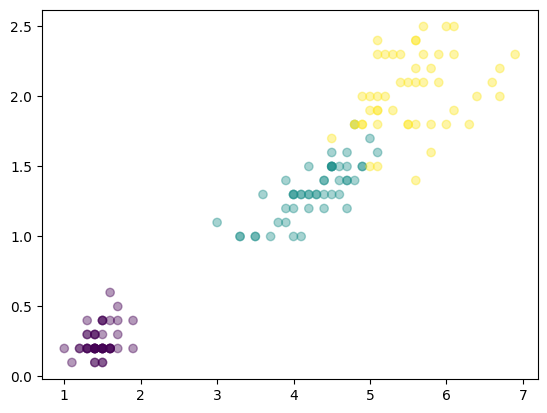

In [2]:
from sklearn.datasets import load_iris
dataset = load_iris()
X = dataset.data[:,2:]
y = dataset.target

import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y, alpha=0.4)
plt.show()

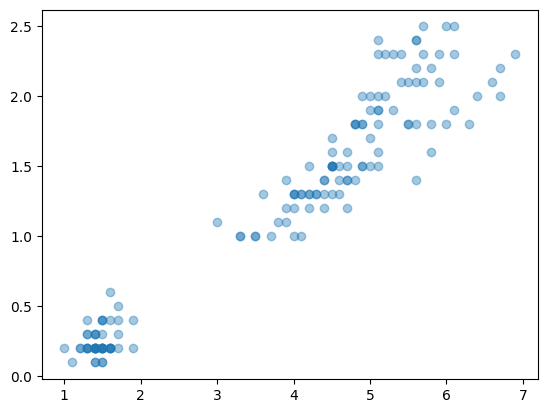

In [3]:
plt.scatter(X[:,0], X[:,1], alpha=0.4)
plt.show()

[[5.62608696 2.04782609]
 [4.29259259 1.35925926]
 [1.462      0.246     ]]


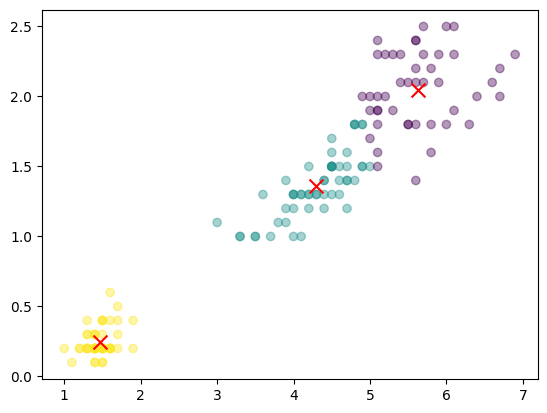

In [78]:
from sklearn.base import BaseEstimator, ClusterMixin, TransformerMixin
import numpy as np

class KMeans(BaseEstimator, ClusterMixin, TransformerMixin):
  def __init__(self, n_clusters=3, max_iter=100):
    self.n_clusters = n_clusters
    self.max_iter = max_iter

  def fit(self, X, y=None):
    max_iter = self.max_iter
    self.centroids = X[np.random.choice(X.shape[0], self.n_clusters)]
    self.previous_centroids = [self.centroids.copy()]
    while max_iter > 0:
      max_iter -= 1
      y_pred = self.predict(X)
      for i in range(self.n_clusters):
        self.centroids[i] = X[y_pred == i].mean(axis=0)
      if np.allclose(self.centroids, self.previous_centroids[-1]):
        break
      self.previous_centroids.append(self.centroids.copy())
    return self

  def distances(self, x):
    differences = self.centroids - x
    squared = differences ** 2
    summed = squared.sum(axis=1)
    root = summed ** 0.5
    return root

  def predict(self, X):
    y_pred = np.empty(X.shape[0])
    for i in range(X.shape[0]):
      distances = self.distances(X[i])
      centroid = np.argmin(distances)
      y_pred[i] = centroid
    return y_pred


kmeans = KMeans(n_clusters=3, max_iter=100)
kmeans.fit(X)
print(kmeans.centroids)
y_pred = kmeans.predict(X)

plt.scatter(X[:,0], X[:,1], c=y_pred, alpha=0.4)
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1],
            marker='x', c='red', s=100)
plt.show()

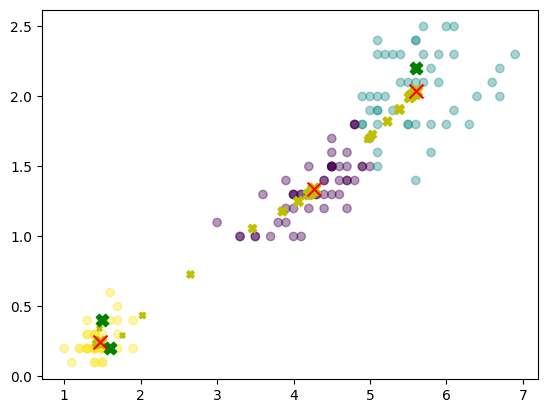

In [79]:
kmeans.fit(X)
y_pred = kmeans.predict(X)

plt.scatter(X[:,0], X[:,1], c=y_pred, alpha=0.4)

for i in range(len(kmeans.previous_centroids)):
  plt.scatter(kmeans.previous_centroids[i][:,0],
              kmeans.previous_centroids[i][:,1],
              marker='X', c='y', s=7*(i+1))
plt.scatter(kmeans.previous_centroids[0][:,0],
            kmeans.previous_centroids[0][:,1],
            marker='X', c='green', s=80)
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1],
            marker='x', c='red', s=100)
plt.show()

In [80]:
from sklearn.cluster import KMeans

kmeans_k3 = KMeans(n_clusters=3).fit(X)
kmeans_k8 = KMeans(n_clusters=8).fit(X)
print(kmeans_k3.inertia_, kmeans_k8.inertia_)

31.412885668276974 8.542616050616054


In [89]:
kmeans_k100 = KMeans(n_clusters=100).fit(X)
print(kmeans_k100.inertia_)

0.012499999999999994


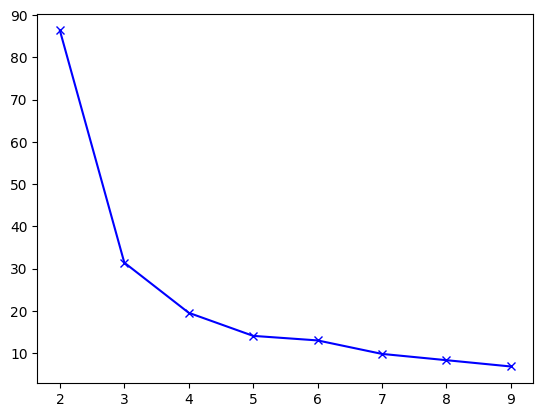

In [92]:
def plot_inertia(X, max_k=10):
  kmeans_per_k = [KMeans(n_clusters=k).fit(X) for k in range(2, max_k)]
  inertias = [model.inertia_ for model in kmeans_per_k]
  plt.plot(range(2, max_k), inertias, 'bx-')
  plt.show()

plot_inertia(X)

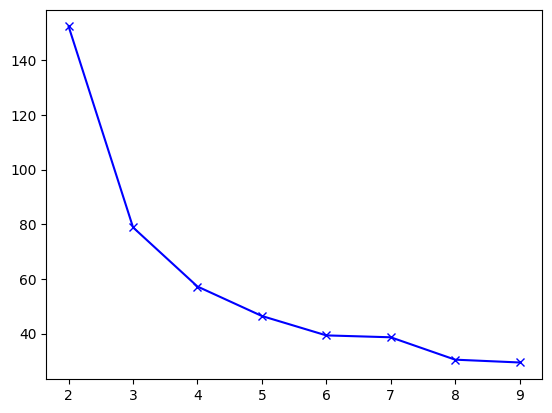

In [93]:
plot_inertia(dataset.data)

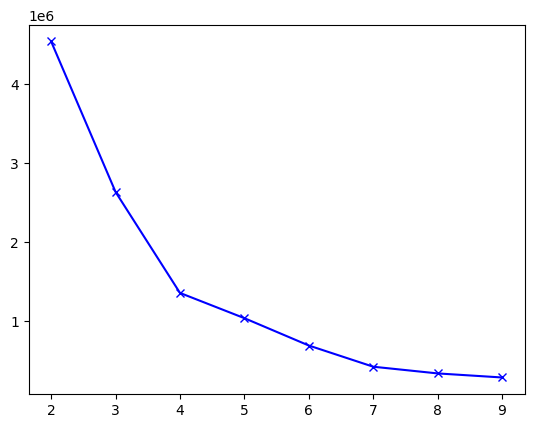

In [94]:
from sklearn.datasets import load_wine
dataset = load_wine()
plot_inertia(dataset.data)